Converted pheno_onehot to np.float32 for 0 nodes.
Nodes — train: 1445 | val: 481 | test: 483
Device: cuda


/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data_dict[key] = torch.as_tensor(value)


Training:   0%|          | 0/200 [00:00<?, ?epoch/s]


Early stopping at epoch 113 — best val F1: 0.6661


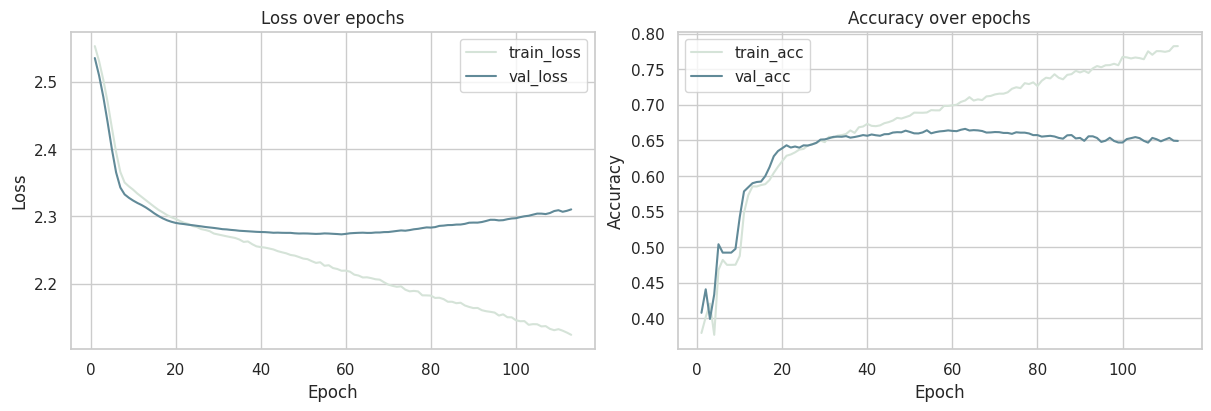

Final epoch - Train acc: 0.7825, Val acc: 0.6492
Best val acc: 0.6492
Restored best model — val F1: 0.6661
Embeddings: (2409, 128)
Splits: 1445 481 483
Saved: /work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_embeddings.pkl
Saved model: /work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_model.pth


In [1]:
# ============================================================
# CONFIG
# ============================================================
DATADIR       = "/work/gr-fe/bryan/data/YEAST/"
GPREFIX       = "KGene"
ATTRS_TO_KEEP = {'pheno_onehot'}
SEED          = 7

# Split
TRAIN_FRAC    = 0.6
VAL_FRAC      = 0.2

# Model
HIDDEN_DIM    = 256
EMB_DIM       = 128
DROPOUT       = 0.5

# Loaders
TRAIN_BATCH   = 512
VAL_BATCH     = 1024
NUM_NEIGHBORS = [15, 10]

# CONTRASTIVE LEARNING
ALPHA_CONTRASTIVE = 0.3
TEMPERATURE = 0.3
USE_JACCARD_WEIGHTS = True

# Optimiser
LR            = 1e-3
WEIGHT_DECAY  = 1e-4

# Training
EPOCHS        = 200
ES_PATIENCE   = 50
ES_MIN_DELTA  = 1e-6
THRESHOLD     = 0.5

# Outputs
GEN_EMB = True
SAVE_MODEL = True

# ============================================================
# IMPORTS
# ============================================================
import os, sys, pickle
import numpy as np
import pandas as pd
from functools import reduce

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch_geometric.utils import from_networkx
from torch_geometric.loader import NeighborLoader

sys.path.insert(0, '../MAIN/')
from helpers import merge_dfs, get_split_indices_from_masks, extract_node_embeddings_fullgraph, save_gnn_embeddings_pickle, save_pytorch_model
from helpers import plot_patient_embeddings, merge_dfs
from network_functions import fix_pheno_onehot_in_graph, nx_to_pyg, load_graph, node_labels
from train import evaluate_multilabel, training_metric_plots
from gnn import EarlyStopping, GraphSageSimple

# ============================================================
# 1) LOAD GRAPH
# ============================================================
g = load_graph(os.path.join(DATADIR, "Networks", f"{GPREFIX}_psn.gpickle"), "PSN")
cnt = fix_pheno_onehot_in_graph(g)
print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

ei, order, weight = nx_to_pyg(g, ATTRS_TO_KEEP, get_weight=True)

# ============================================================
# 2) LOAD FEATURES
# ============================================================
with open(os.path.join(DATADIR, "02_processed", "EXPR.processed.pkl"), "rb") as f:
    data_expr = pickle.load(f)
expr_df = data_expr["expr"]

all_nodes = sorted(set(g.nodes))
expr_df   = expr_df.loc[expr_df.index.intersection(all_nodes)].copy()

meta    = node_labels(g)
meta    = pd.DataFrame(np.float32(meta.values), index=meta.index)
h_df    = reduce(merge_dfs, [expr_df]).reindex(all_nodes)
meta_df = meta.reindex(all_nodes)

x = torch.tensor(h_df.values,    dtype=torch.float32)
y = torch.tensor(meta_df.values, dtype=torch.float32)

# ============================================================
# 3) PyG DATA + MASKS
# ============================================================
data   = from_networkx(g)
data.x = x
data.y = y

N       = len(all_nodes)
gen     = torch.Generator().manual_seed(SEED)
perm    = torch.randperm(N, generator=gen)
n_train = int(TRAIN_FRAC * N)
n_val   = int(VAL_FRAC   * N)

data.train_mask = torch.zeros(N, dtype=torch.bool)
data.val_mask   = torch.zeros(N, dtype=torch.bool)
data.test_mask  = torch.zeros(N, dtype=torch.bool)
data.train_mask[perm[:n_train]]                    = True
data.val_mask  [perm[n_train:n_train + n_val]]     = True
data.test_mask [perm[n_train + n_val:]]            = True

print(f"Nodes — train: {data.train_mask.sum()} | val: {data.val_mask.sum()} | test: {data.test_mask.sum()}")

# ============================================================
# 4) LOADERS
# ============================================================
_loader_kwargs = dict(num_neighbors=NUM_NEIGHBORS, persistent_workers=False)

train_loader = NeighborLoader(data, input_nodes=data.train_mask, batch_size=TRAIN_BATCH, shuffle=True,  **_loader_kwargs)
val_loader   = NeighborLoader(data, input_nodes=data.val_mask,   batch_size=VAL_BATCH,   shuffle=False, **_loader_kwargs)
test_loader  = NeighborLoader(data, input_nodes=data.test_mask,  batch_size=VAL_BATCH,   shuffle=False, **_loader_kwargs)

# ============================================================
# 5) SUPERVISED CONTRASTIVE LOSS (MULTI-LABEL)
# ============================================================
def multilabel_overlap_matrix(y_batch: torch.Tensor) -> torch.Tensor:
    overlap_count = y_batch.float() @ y_batch.float().T
    return overlap_count > 0

def jaccard_matrix(y_batch: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    y = y_batch.float()
    inter = y @ y.T
    row_sums = y.sum(dim=1, keepdim=True)
    union = row_sums + row_sums.T - inter
    return inter / (union + eps)

def supervised_contrastive_loss_multilabel(
    z: torch.Tensor,
    y: torch.Tensor,
    temperature: float = 0.1,
    use_jaccard_weights: bool = True,
    eps: float = 1e-8,
) -> torch.Tensor:
    """
    z: [B, D] embeddings for *seed nodes* in minibatch
    y: [B, C] multi-hot labels for *seed nodes*
    """
    device = z.device
    B = z.size(0)

    z = F.normalize(z, p=2, dim=1)
    logits = (z @ z.T) / temperature
    logits = logits - logits.max(dim=1, keepdim=True).values.detach()

    self_mask = torch.eye(B, device=device, dtype=torch.bool)
    pos_mask = multilabel_overlap_matrix(y).to(device) & (~self_mask)

    pos_counts = pos_mask.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)

    exp_logits = torch.exp(logits) * (~self_mask)
    denom = exp_logits.sum(dim=1, keepdim=True) + eps
    log_prob = logits - torch.log(denom)

    if use_jaccard_weights:
        w = jaccard_matrix(y).to(device) * pos_mask.float()
        w_sums = w.sum(dim=1, keepdim=True) + eps
        mean_log_prob_pos = (w * log_prob).sum(dim=1, keepdim=True) / w_sums
    else:
        mean_log_prob_pos = (log_prob * pos_mask.float()).sum(dim=1, keepdim=True) / (pos_counts.unsqueeze(1) + eps)

    loss_per_anchor = -mean_log_prob_pos.squeeze(1)
    return loss_per_anchor[valid].mean()

# ============================================================
# 6) MODEL, OPTIMISER, EARLY STOPPING
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = GraphSageSimple(in_dim=x.shape[1], hidden_dim=HIDDEN_DIM, emb_dim=EMB_DIM, num_labels=y.shape[1], dropout=DROPOUT).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
es    = EarlyStopping(patience=ES_PATIENCE, min_delta=ES_MIN_DELTA)

# ============================================================
# 7) TRAINING LOOP
# ============================================================
history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
pbar    = tqdm(range(1, EPOCHS + 1), desc="Training", unit="epoch")

for epoch in pbar:
    # ---- train ----
    model.train()
    total_loss, total_seeds = 0.0, 0
    tr_tp = tr_fp = tr_fn = 0.0  # for train micro-F1

    for batch in train_loader:
        batch      = batch.to(device)
        seed_count = batch.batch_size

        optim.zero_grad(set_to_none=True)
        _, logits_all = model(batch.x, batch.edge_index)

        h_seed = logits_all[:seed_count]
        y_seed = batch.y[:seed_count]
        bce = F.binary_cross_entropy_with_logits(h_seed,y_seed)
        con = supervised_contrastive_loss_multilabel(
            z=h_seed,
            y=y_seed,
            temperature=TEMPERATURE,
            use_jaccard_weights=USE_JACCARD_WEIGHTS,
        )
        loss = bce + (ALPHA_CONTRASTIVE*con)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()

        total_loss  += float(loss.detach().cpu()) * seed_count
        total_seeds += seed_count

        with torch.no_grad():
            y_pred = (torch.sigmoid(logits_all[:seed_count]) >= THRESHOLD).to(torch.int32)
            y_true = batch.y[:seed_count].to(torch.int32)
            tr_tp += float((y_pred &  y_true      ).sum())
            tr_fp += float((y_pred & (1 - y_true) ).sum())
            tr_fn += float(((1 - y_pred) & y_true ).sum())

    train_loss    = total_loss / max(total_seeds, 1)
    train_micro_f1 = (2 * tr_tp) / (2 * tr_tp + tr_fp + tr_fn + 1e-8)

    # ---- val ----
    model.eval()
    tp = fp = fn = 0.0
    val_total_loss, val_total_seeds = 0.0, 0

    with torch.no_grad():
        for batch in val_loader:
            batch      = batch.to(device)
            seed_count = batch.batch_size
            _, logits_all = model(batch.x, batch.edge_index)

            logits_seed = logits_all[:seed_count]
            y_true      = batch.y[:seed_count]

            val_bce_batch = F.binary_cross_entropy_with_logits(logits_seed, y_true)
            val_con_batch = supervised_contrastive_loss_multilabel(
                                z=logits_seed,
                                y=y_true,
                                temperature=TEMPERATURE,
                                use_jaccard_weights=USE_JACCARD_WEIGHTS,
                            ) 
            val_loss_batch = val_bce_batch + ALPHA_CONTRASTIVE*val_con_batch
            
            val_total_loss  += float(val_loss_batch) * seed_count
            val_total_seeds += seed_count

            y_pred = (torch.sigmoid(logits_seed) >= THRESHOLD).to(torch.int32)
            y_true = y_true.to(torch.int32)

            tp += float((y_pred &  y_true          ).sum())
            fp += float((y_pred & (1 - y_true)     ).sum())
            fn += float(((1 - y_pred) &  y_true    ).sum())

    micro_f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    val_loss = val_total_loss / max(val_total_seeds, 1)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_micro_f1)   
    history["val_loss"].append(val_loss)           
    history["val_acc"].append(micro_f1)

    pbar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_F1":     f"{micro_f1:.4f}",
        "es_counter": f"{es.counter}/{es.patience}",
    })

    es.step(micro_f1, model)
    if es.stop:
        print(f"\nEarly stopping at epoch {epoch} — best val F1: {es.best_score:.4f}")
        break

training_metric_plots(history, micro_f1)
es.restore(model)
print(f"Restored best model — val F1: {es.best_score:.4f}")

# ============================================================
# 8) TEST EVALUATION
# ============================================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch      = batch.to(device)
        seed_count = batch.batch_size
        _, logits_all = model(batch.x, batch.edge_index)

        all_preds.append ((torch.sigmoid(logits_all[:seed_count]) >= THRESHOLD).to(torch.int32).cpu())
        all_labels.append(batch.y[:seed_count].to(torch.int32).cpu())

evaluate_multilabel(
    torch.cat(all_labels).numpy(),
    torch.cat(all_preds ).numpy(),
)

# ============================================================
# 9) Extract GNN node embeddings + (train/val/test) indices
# from your existing PyG `data` object and trained `model`. 
# Save model and embeddings 
# ============================================================

if GEN_EMB : 
    train_idx, val_idx, test_idx = get_split_indices_from_masks(data)
    
    # Full-graph embeddings (most convenient for RAkEL / sklearn training)
    H = extract_node_embeddings_fullgraph(model, data, device=device, return_logits=False)
    
    print("Embeddings:", H.shape)
    print("Splits:", len(train_idx), len(val_idx), len(test_idx))
    
    # Now you can build X_train/X_val/X_test for sklearn:
    X_train = H[train_idx]
    X_val   = H[val_idx]
    X_test  = H[test_idx]
    
    # And labels for sklearn (dense multi-hot)
    y_np = data.y.cpu().numpy()
    y_train = y_np[train_idx]
    y_val   = y_np[val_idx]
    y_test  = y_np[test_idx]
    
    
    out_file = save_gnn_embeddings_pickle(
        out_path="/work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_embeddings.pkl",
        H=H,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        y=y_np,
        extra={
            "model": "GraphSageSimple",
            "hidden_dim": HIDDEN_DIM,
            "emb_dim": EMB_DIM,
            "seed": SEED,
        }
    )
    print("Saved:", out_file)

if SAVE_MODEL : 
    model_file = save_pytorch_model(
    model=model,
    path="/work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_model",
    optimizer=None,  # or pass your optimizer if you want checkpoint-style saving
    extra={
        "model": "MOGSage",
        "hidden_dim": HIDDEN_DIM,
        "emb_dim": EMB_DIM,
        "seed": SEED,
    },
    save_entire_model=False,  # recommended
    )
    print("Saved model:", model_file)